# Internacoes x Qualidade do ar

Este notebook integra e analisa **internações por doenças respiratórias (SUS)** e **condições de qualidade do ar/meteorologia (DataRio)** no município do **Rio de Janeiro**, com o objetivo de **entender relações e preparar features** para prever:
- **`internacoes_d1`** (D+1) e **`internacoes_d7`** (D+7).

**O que é feito aqui (resumo):**
- Unificação das bases por **data** e criação dos **alvos** (`internacoes_d1`, `internacoes_d7`).
- Análises de correlação (ACF/PACF, CCF por lags), **médias móveis** (MM3…MM150) e **correlação rolante** (janela anual).
- **Estudo de eventos** (picos de poluentes via MM7) e **comparação visual** alvo × poluentes (z-score, séries semanais).
- Seleção de **janelas e defasagens candidatas** sem vazamento (sempre info ≤ _t_).


## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf as pacf_vals_fn
import seaborn as sns

## Unificação dos datasets (Internações × Ambiente)

**Objetivo:** juntar a série diária de **internações respiratórias** ao dataset diário de **variáveis ambientais** do Rio de Janeiro.

In [2]:
url_internacoes   = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTERNACOES_DOENCA_RESP_RJ.csv"
url_qualiar = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes   = pd.read_csv(url_internacoes,  encoding="utf-8")   
df_qualiar = pd.read_csv(url_qualiar, encoding="utf-8")  

df_unificado = pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner").sort_values("data_dia").reset_index(drop=True)

print("Dimensões do unificado:", df_unificado.shape)
print("Intervalo de datas:", df_unificado["data_dia"].min(), "→", df_unificado["data_dia"].max())
print("\nColunas:", df_unificado.columns.tolist())
print("\nAmostra:")
display(df_unificado.head())


Dimensões do unificado: (4747, 20)
Intervalo de datas: 2012-01-01 → 2024-12-29

Colunas: ['data_dia', 'ano', 'mes', 'dia', 'chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'AQI', 'Qualidade_do_Ar', 'num_internacoes', 'internacoes_d1', 'internacoes_d7']

Amostra:


,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,AQI,Qualidade_do_Ar,num_internacoes,internacoes_d1,internacoes_d7
0,2012-01-01,2012,1,1,1.693921,-0.051742,1.917484,0.693390,-1.964227,-0.759897,-1.150568,-0.822666,-0.917604,-0.869809,0.035735,-1.477106,1.0,143,0.0,13.0
1,2012-01-02,2012,1,2,1.816431,-0.943870,2.236553,-0.302832,0.226355,-0.371044,-0.168446,-1.346559,-1.232715,-2.319570,-1.367160,-2.071418,1.0,0,65.0,65.0
2,2012-01-03,2012,1,3,-0.766991,-0.315602,0.424084,-0.778747,0.702674,-0.216149,0.184335,-0.217835,-1.762871,-0.854360,-1.570305,-1.235923,1.0,65,39.0,65.0
3,2012-01-04,2012,1,4,-0.698032,-0.000874,0.122627,-0.612457,1.238748,0.753858,1.036985,-0.588549,-0.720611,0.202152,0.150301,-0.029610,1.0,39,52.0,26.0
4,2012-01-05,2012,1,5,-0.839592,0.145484,0.365842,-0.656019,0.654600,0.333601,0.472384,-0.617587,0.063417,-0.020606,-0.398419,0.137534,1.0,52,26.0,39.0


In [3]:
project_root = Path().resolve().parents[1]  
output_dir = project_root / "data" 
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "INTERNACOES_x_QUALIAR.csv"
df_unificado.to_csv(output_csv_path, index=False, encoding="utf-8")

## Análise de Correlação

### PACF das internações diárias

Objetivo: visualizar a **dependência temporal parcial** da série `num_internacoes`.  
Observação: o PACF é mais informativo em séries **estacionárias**; se houver tendência/sazonalidade, considere usar a versão **diferenciada** (exemplo comentado no código).


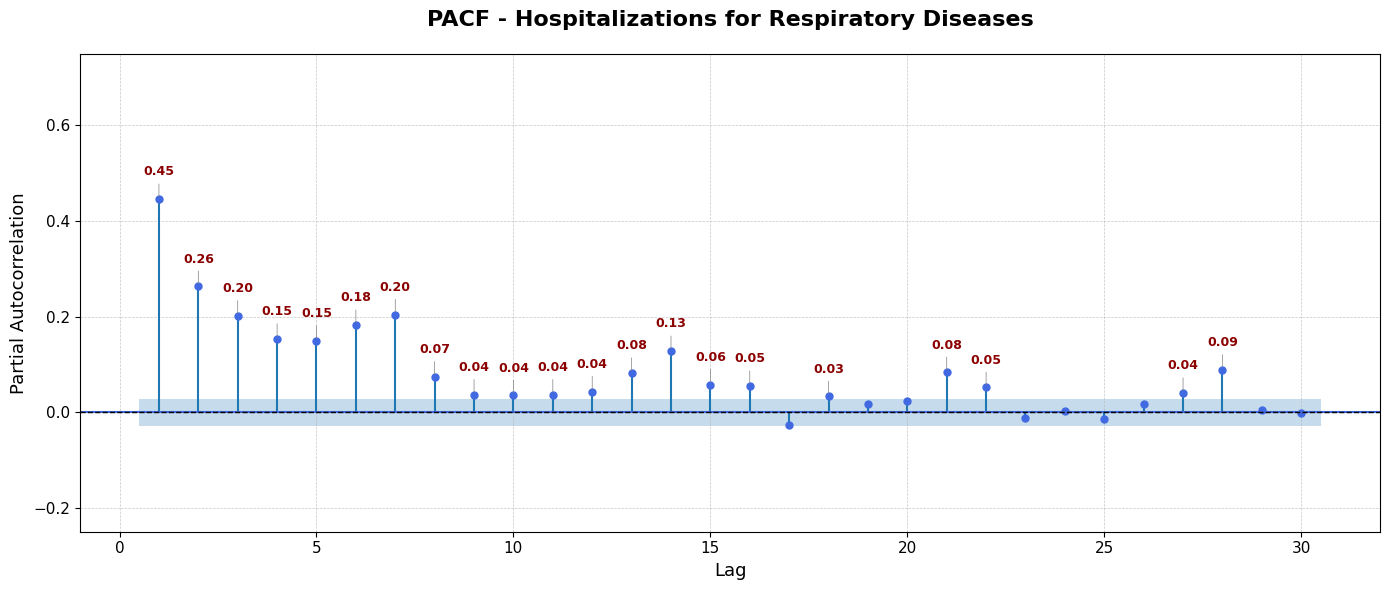

In [4]:
df_ = df_unificado.copy()
df_["data_dia"] = pd.to_datetime(df_["data_dia"], errors="coerce")
df_ = df_.dropna(subset=["data_dia"]).sort_values("data_dia")

serie = pd.to_numeric(df_["num_internacoes"], errors="coerce").dropna()

max_lags = 30
lags = int(min(max_lags, max(1, len(serie) - 1)))

fig, ax = plt.subplots(figsize=(14, 6))

try:
    plot_pacf(
        serie,
        lags=lags,
        method='ywm',
        ax=ax,
        color='royalblue',     
        zero=False,
        alpha=0.05,
    )
except TypeError:
    plot_pacf(
        serie,
        lags=lags,
        method='ywm',
        ax=ax,
        zero=False,
        alpha=0.05,
        use_vlines=True,
        vlines_kwargs={"colors": "royalblue"},
        marker='o',
        markersize=4,
    )

ax.set_ylim(-0.25, 0.75)
ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_title("PACF - Hospitalizations for Respiratory Diseases", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Partial Autocorrelation", fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Valores da PACF para anotar e intervalo normal aproximado
pacf_vals = pacf_vals_fn(serie, nlags=lags, method='ywm')
conf_interval = 1.96 / np.sqrt(len(serie))

for i, val in enumerate(pacf_vals[1:], start=1):
    if abs(val) > conf_interval:
        ax.annotate(
            f'{val:.2f}',
            xy=(i, val),
            xytext=(i, val + 0.05 * np.sign(val)),
            ha='center',
            fontsize=9,
            color='darkred',
            fontweight='bold',
            arrowprops=dict(arrowstyle='-', lw=0.5, color='gray')
        )

plt.tight_layout()
plt.show()

#### PACF 

- **Lag 1 alto (~0,45):** forte dependência de curto prazo.
- **Lags 2–6 ainda significativos:** memória por vários dias.
- **Sazonalidade semanal:** picos nos lags **7, 14, 21, 28**.

**Implicação:** use AR curto (ex.: **lags 1–3**) + **componente semanal** (dummy de dia da semana ou sazonalidade s=7). Em seguida, confira ACF e, se preciso, diferencie sazonalmente (7 dias).


### Correlação entre a média móvel de internações (até t) e os alvos D+1/D+7

**O que é:**  
Calculamos a correlação entre a **média móvel do número de internações até o dia _t_** (ex.: MM3, MM7, MM14) e os **alvos futuros**:
- `internacoes_d1` → internações no **dia t+1**  
- `internacoes_d7` → internações no **dia t+7**

**Por que fazemos:**  
- A série de internações tem **alta persistência** e **padrão semanal**; a média móvel resume esse comportamento recente sem usar informação do futuro (**sem vazamento**).  
- Ajuda a identificar **qual janela** (3, 7, 14… dias) melhor resume a dinâmica recente para **prever** D+1 e D+7.  
- Serve de **baseline forte** e orienta a **engenharia de atributos** (quais janelas incluir no modelo).

    window          target     n  spearman   pearson
0        3  internacoes_d1  4744  0.547937  0.533434
1        7  internacoes_d1  4740  0.600294  0.601035
2       14  internacoes_d1  4733  0.610427  0.612064
3       21  internacoes_d1  4726  0.608246  0.614448
4       30  internacoes_d1  4717  0.605062  0.613471
5       60  internacoes_d1  4687  0.585634  0.606657
6        3  internacoes_d7  4738  0.546728  0.538606
7        7  internacoes_d7  4734  0.578757  0.572076
8       14  internacoes_d7  4727  0.591336  0.593229
9       21  internacoes_d7  4720  0.590077  0.597007
10      30  internacoes_d7  4711  0.592737  0.602103
11      60  internacoes_d7  4681  0.573521  0.597649

Spearman (janela x alvo):
 target  internacoes_d1  internacoes_d7
window                                
3                0.548           0.547
7                0.600           0.579
14               0.610           0.591
21               0.608           0.590
30               0.605           0.593
60        

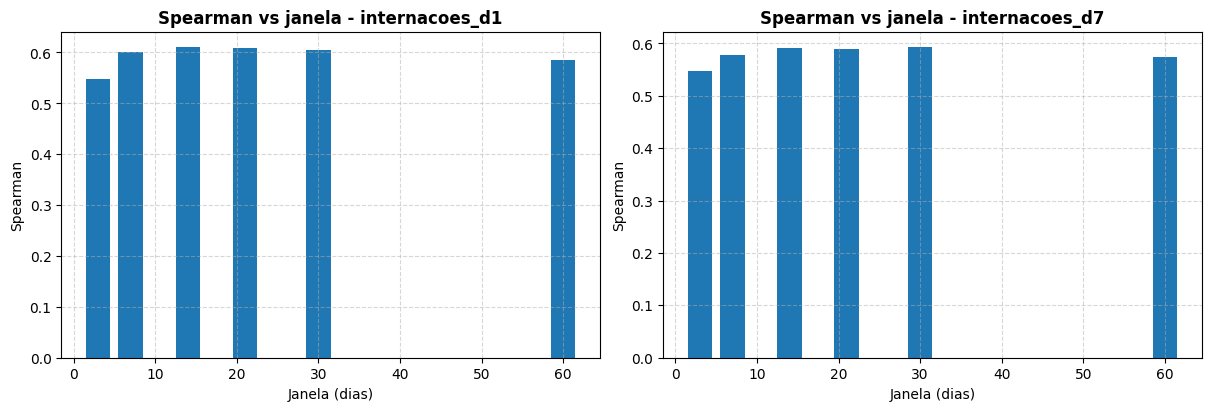

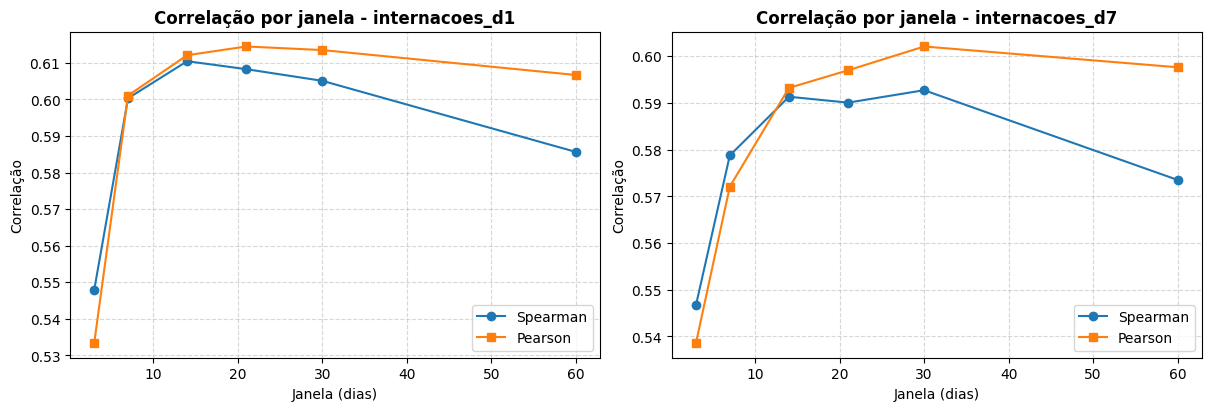

In [5]:
df = df_unificado.copy()
df["data_dia"] = pd.to_datetime(df["data_dia"], errors="coerce")
df = df.dropna(subset=["data_dia"]).sort_values("data_dia")

y = pd.to_numeric(df["num_internacoes"], errors="coerce")
if "internacoes_d1" not in df.columns: df["internacoes_d1"] = y.shift(-1)
if "internacoes_d7" not in df.columns: df["internacoes_d7"] = y.shift(-7)
targets = [t for t in ["internacoes_d1","internacoes_d7"] if t in df.columns]

windows = [3, 7, 14, 21, 30, 60]
for w in windows:
    df[f"y_mm{w}"] = y.rolling(window=w, min_periods=w).mean()

rows = []
for w in windows:
    x = pd.to_numeric(df[f"y_mm{w}"], errors="coerce")
    for tgt in targets:
        y_h = pd.to_numeric(df[tgt], errors="coerce")
        mask = x.notna() & y_h.notna()
        n = int(mask.sum())
        spearman = df.loc[mask, [f"y_mm{w}", tgt]].corr(method="spearman").iloc[0,1] if n >= 5 else np.nan
        pearson  = df.loc[mask, [f"y_mm{w}", tgt]].corr(method="pearson").iloc[0,1]  if n >= 5 else np.nan
        rows.append({"window": w, "target": tgt, "n": n, "spearman": spearman, "pearson": pearson})

res = pd.DataFrame(rows).sort_values(["target","window"]).reset_index(drop=True)
print(res)

pivot_s = res.pivot(index="window", columns="target", values="spearman").round(3)
print("\nSpearman (janela x alvo):\n", pivot_s)

best = (res.assign(abs_s=res["spearman"].abs())
          .sort_values(["target","abs_s"], ascending=[True, False])
          .groupby("target").head(1)
          .drop(columns="abs_s"))
print("\nMelhor janela por alvo (Spearman):\n", best)

fig, axes = plt.subplots(1, len(targets), figsize=(6*len(targets), 4), constrained_layout=True)
if len(targets) == 1: axes = [axes]
for ax, tgt in zip(axes, targets):
    sub = res[res["target"] == tgt]
    ax.bar(sub["window"], sub["spearman"], width=3)
    ax.set_title(f"Spearman vs janela - {tgt}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Janela (dias)"); ax.set_ylabel("Spearman")
    ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

fig, axes = plt.subplots(1, len(targets), figsize=(6*len(targets), 4), constrained_layout=True)
if len(targets) == 1: axes = [axes]
for ax, tgt in zip(axes, targets):
    sub = res[res["target"] == tgt]
    ax.plot(sub["window"], sub["spearman"], marker="o", label="Spearman")
    ax.plot(sub["window"], sub["pearson"],  marker="s", label="Pearson")
    ax.set_title(f"Correlação por janela - {tgt}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Janela (dias)"); ax.set_ylabel("Correlação")
    ax.grid(True, linestyle="--", alpha=0.5); ax.legend()
plt.show()


#### Resumo — MM de internações vs D+1/D+7

**Resultados (Spearman):**
- **D+1:** melhor **MM14** (0,610) — leve superior a MM21/MM30.
- **D+7:** melhor **MM30** (0,593).
- Faixa geral: **0,55–0,61** (persistência alta).  
- Aumenta de MM3 → MM14/30 e **satura**; **MM60** perde força.

**Implicação prática:**  
Use **MM14** (D+1) e **MM30** (D+7) como features fortes; combine com **lags de y (1–3, 7)** e **dia-da-semana**. Valide com **split temporal** e compare ao **naïve s=7**.


### Correlação (Spearman) entre alvos e features (lag 0)

Objetivo: medir a associação **no mesmo dia (lag 0)** entre os alvos **`internacoes_d1`** e **`internacoes_d7`** e as variáveis ambientais/meteorológicas.  
Abaixo, dois gráficos de barras (um por alvo), com as features **ordenadas por correlação**.


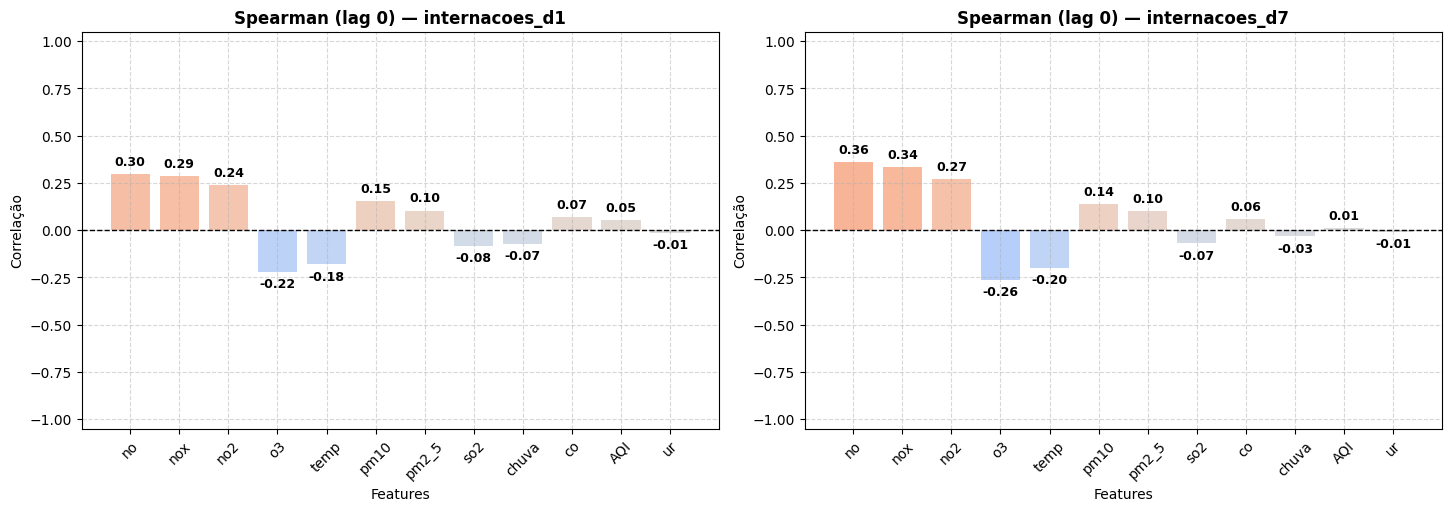

,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,AQI
internacoes_d1,-0.071,-0.181,-0.014,0.070,0.297,0.239,0.287,-0.081,-0.222,0.153,0.104,0.053
internacoes_d7,-0.032,-0.199,-0.009,0.059,0.359,0.273,0.336,-0.069,-0.264,0.140,0.101,0.013


In [6]:
df = df_unificado.copy()
df["data_dia"] = pd.to_datetime(df["data_dia"], errors="coerce")
df = df.dropna(subset=["data_dia"]).sort_values("data_dia")

targets = ["internacoes_d1", "internacoes_d7"]
feature_candidates = ["chuva","temp","ur","co","no","no2","nox","so2","o3","pm10","pm2_5","AQI"]
features = [c for c in feature_candidates if c in df.columns]
if not features:
    raise ValueError("Nenhuma feature candidata encontrada.")

cols_needed = [c for c in targets if c in df.columns] + features
df_valid = df[cols_needed].dropna()

corr_series = {}
for t in targets:
    if t in df_valid.columns:
        s = df_valid[features].corrwith(df_valid[t], method="spearman")
        corr_series[t] = s.sort_values(key=lambda x: x.abs(), ascending=False)

corr_mat = pd.DataFrame(
    {t: df_valid[features].corrwith(df_valid[t], method="spearman") for t in corr_series}
).T[features]

n_tg = len(corr_series)
fig, axes = plt.subplots(1, n_tg, figsize=(max(10, 1.2*len(features))*n_tg/2, 5), constrained_layout=True)
if n_tg == 1:
    axes = [axes]

for ax, (t, s) in zip(axes, corr_series.items()):
    vals = s.values
    idx = s.index
    colors = plt.cm.coolwarm((vals + 1) / 2)
    bars = ax.bar(idx, vals, color=colors)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(f"Spearman (lag 0) — {t}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Features")
    ax.set_ylabel("Correlação")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle="--", alpha=0.5)

    offset = 0.03
    for rect, val in zip(bars, vals):
        x = rect.get_x() + rect.get_width()/2
        y = val + offset if val >= 0 else val - offset
        va = "bottom" if val >= 0 else "top"
        ax.text(x, y, f"{val:.2f}", ha="center", va=va, fontsize=9, fontweight="bold")

plt.show()

display(corr_mat.round(3))


#### Correlação (Spearman, lag 0)

- **Tráfego (NO, NOx, NO₂):** maior associação **positiva**  
  - D+1: NO **0,30**, NOx **0,29**, NO₂ **0,24**  
  - D+7: NO **0,36**, NOx **0,34**, NO₂ **0,27**
- **Ozônio (O₃):** associação **negativa** (D+1 **−0,22**; D+7 **−0,26**).
- **Temperatura:** **negativa** (D+1 **−0,18**; D+7 **−0,20**).
- **Material particulado:** **pequena positiva** (PM₁₀ ~**0,15**; PM₂.₅ ~**0,10**).
- **Chuva/UR/CO/AQI/SO₂:** efeitos **fracos** (|ρ| ≤ ~0,08; AQI ≈ 0).

> Leitura: níveis mais altos de **NO/NOx/NO₂** no dia tendem a acompanhar **mais internações**; **O₃** e **temperatura** mostram relação inversa. As magnitudes são **moderadas**, sugerindo influência adicional de calendário e persistência da série.


### Heatmap CCF (Spearman) — `internacoes_d1` / `internacoes_d7` × features (lags 0..14)

- Cada célula é a **correlação de Spearman** entre o **alvo** (`y_{t+1}` ou `y_{t+7}`) e a **feature observada até o dia t**:  
  Coluna **lag k** = correlação entre `y_{t+h}` e `X_{t−k}` (implementado como `X.shift(k)`).
- Use isso para identificar **quais variáveis** e **quais defasagens** explicam melhor cada horizonte.


C:\Users\jhter\AppData\Local\Temp\ipykernel_43744\4280787095.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


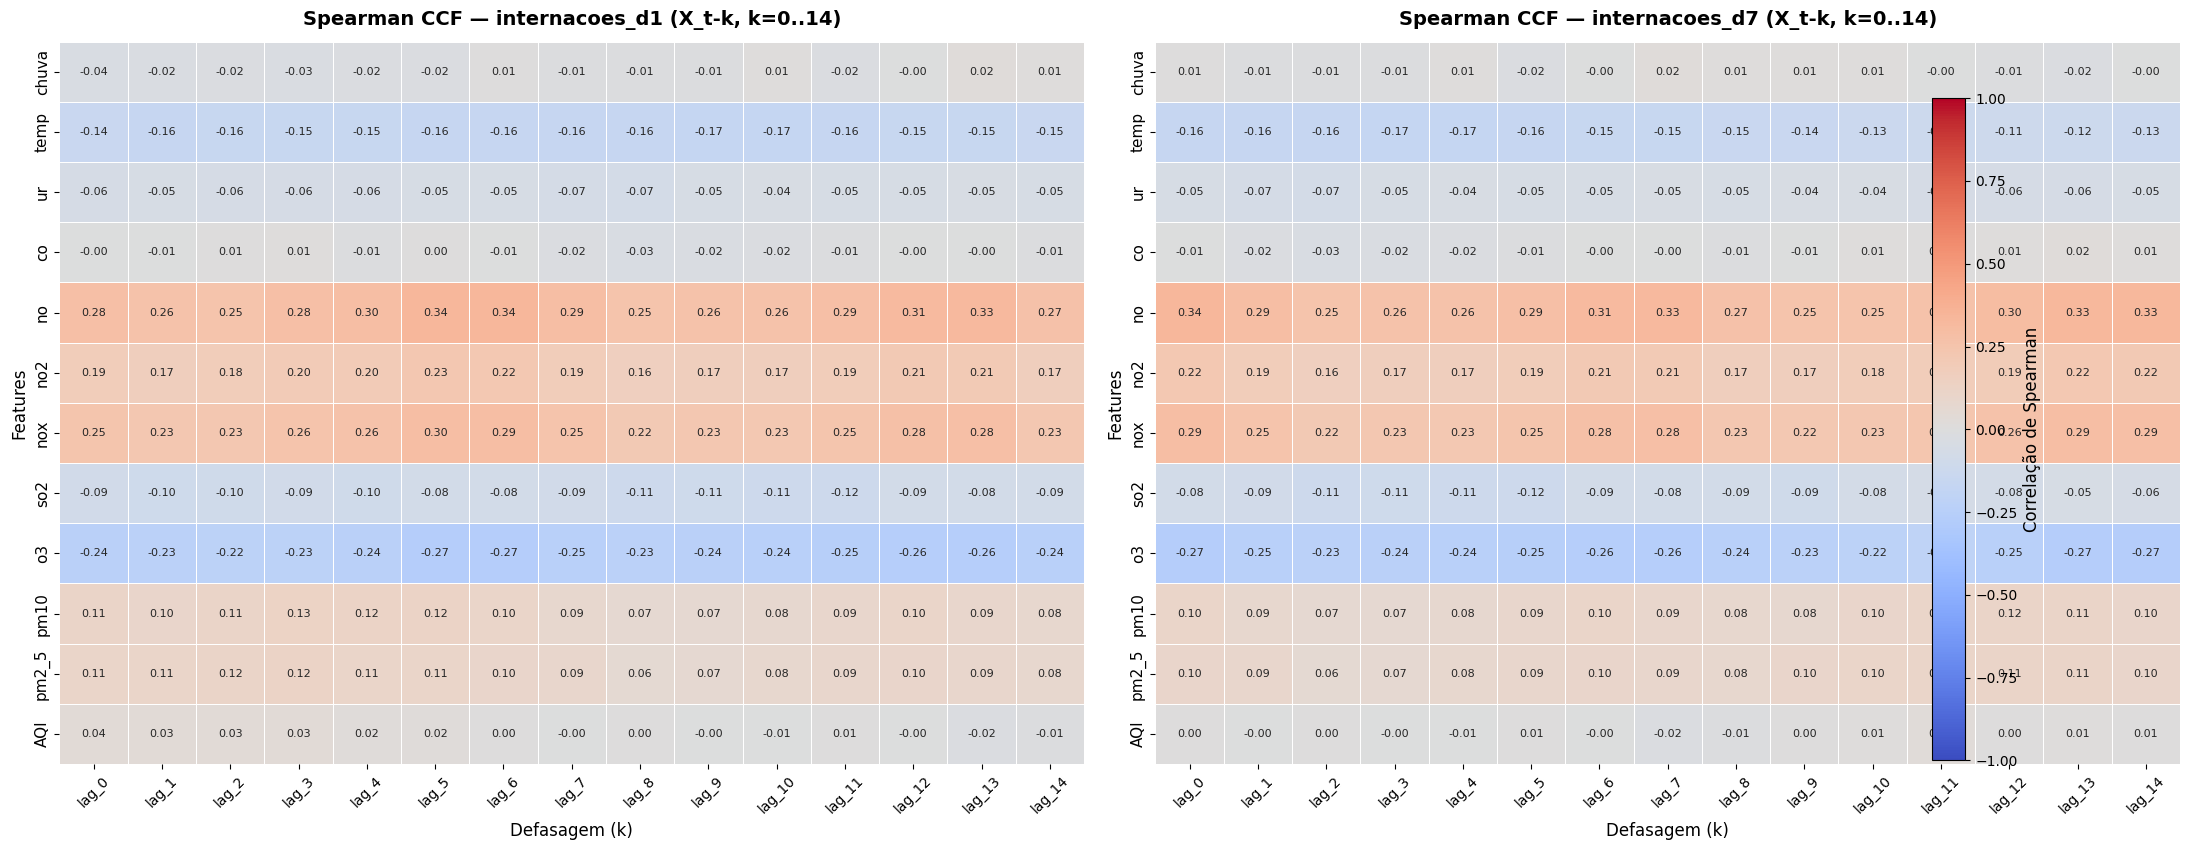


Top lags por feature para internacoes_d1:


,lag_max_abs,corr
no,lag_6,0.338985
nox,lag_5,0.295943
o3,lag_6,-0.273026
no2,lag_5,0.227313
temp,lag_9,-0.170277
pm10,lag_3,0.127603
pm2_5,lag_3,0.123471
so2,lag_11,-0.116755
ur,lag_8,-0.072086
AQI,lag_0,0.037933



Top lags por feature para internacoes_d7:


,lag_max_abs,corr
no,lag_0,0.338985
nox,lag_0,0.292812
o3,lag_0,-0.273026
no2,lag_13,0.224404
temp,lag_3,-0.170277
so2,lag_5,-0.116755
pm10,lag_12,0.115437
pm2_5,lag_12,0.114155
ur,lag_2,-0.072086
co,lag_2,-0.034696


In [7]:
df = df_unificado.copy()
df["data_dia"] = pd.to_datetime(df["data_dia"], errors="coerce")
df = df.dropna(subset=["data_dia"]).sort_values("data_dia")

targets = ["internacoes_d1", "internacoes_d7"]
feature_candidates = ["chuva","temp","ur","co","no","no2","nox","so2","o3","pm10","pm2_5","AQI"]
features = [c for c in feature_candidates if c in df.columns]
if not features:
    raise ValueError("Nenhuma feature ambiental encontrada no DataFrame.")

max_lag = 14
lags = list(range(0, max_lag + 1))

corr_mats = {}
for tgt in targets:
    y = pd.to_numeric(df[tgt], errors="coerce")
    mat = pd.DataFrame(index=features, columns=[f"lag_{k}" for k in lags], dtype=float)
    for k in lags:
        xk = df[features].apply(pd.to_numeric, errors="coerce").shift(k)
        for feat in features:
            v = xk[feat]
            m = y.notna() & v.notna()
            mat.loc[feat, f"lag_{k}"] = y[m].corr(v[m], method="spearman") if m.sum() >= 5 else np.nan
    corr_mats[tgt] = mat

cell_w, cell_h = 0.6, 0.55
fig_w = max(10, cell_w * len(lags)) * len(targets) + 2
fig_h = max(6, cell_h * len(features) + 2)

fig, axes = plt.subplots(1, len(targets), figsize=(fig_w, fig_h))
if len(targets) == 1:
    axes = [axes]

vmin, vmax, cmap = -1, 1, "coolwarm"
for ax, tgt in zip(axes, targets):
    mat = corr_mats[tgt]
    sns.heatmap(
        mat, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, center=0,
        annot=True, fmt=".2f", annot_kws={"size":8},
        linewidths=0.6, linecolor="white", cbar=False
    )
    ax.set_title(f"Spearman CCF — {tgt} (X_t-k, k=0..{max_lag})", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Defasagem (k)", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    ax.tick_params(axis="x", labelrotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=11)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Correlação de Spearman", fontsize=12)

plt.tight_layout()
plt.show()

for tgt in targets:
    mat = corr_mats[tgt].copy()
    best = mat.abs().idxmax(axis=1).to_frame("lag_max_abs")
    best["corr"] = [mat.loc[idx, lag] for idx, lag in zip(best.index, best["lag_max_abs"])]
    best = best.sort_values("corr", key=lambda s: s.abs(), ascending=False)
    print(f"\nTop lags por feature para {tgt}:")
    display(best.head(10))

#### CCF (Spearman) — melhores defasagens por feature

**Leitura geral**
- Família **NO/NOx/NO₂** é o **sinal mais forte e positivo**; **O₃** é **negativo**.
- **Temperatura** tende a **reduzir** internações (negativa).  
- **Particulado** (PM₁₀/PM₂.₅) é **positivo**, porém **moderado**.  
- **SO₂/UR/CO** têm efeitos **fracos**.

**D+1 (`internacoes_d1`) — pico em defasagens ~5–6 dias**
- **NO**: **lag 6** = **0,339**  
- **NOx**: **lag 5** = **0,296**  
- **NO₂**: **lag 5** = **0,227**  
- **O₃**: **lag 6** = **−0,273**  
- **Temp**: **lag 9** = **−0,170**  
- **PM₁₀/PM₂.₅**: **lag 3** ≈ **0,13**  
→ Indica **efeito defasado** próximo de **uma semana**.

**D+7 (`internacoes_d7`) — pico no mesmo dia e ecos semanais**
- **NO**: **lag 0** = **0,339**  
- **NOx**: **lag 0** = **0,293**  
- **O₃**: **lag 0** = **−0,273**  
- **NO₂**: **lag 13** = **0,224**  
- **PM₁₀/PM₂.₅**: **lag 12** ≈ **0,115**  
- **Temp**: **lag 3** = **−0,170**  
→ Para o horizonte semanal, o **valor do dia (lag 0)** já carrega muita informação, com **ecos** próximos a 7/14 dias (sazonalidade semanal).

**Nota:** As correlações são **marginais** (não ajustadas). Parte do padrão pode refletir **calendário** e **colinearidade** (ex.: **O₃** vs **NOx**). Use essas defasagens como **candidatas** para features, mantendo apenas **lags ≤ t**.


### Correlação com janelas móveis (efeito acumulado)
Correlação de **Spearman** entre os **alvos** (`internacoes_d1`, `internacoes_d7`) e as **features no dia t** (`X_t`) e suas **médias móveis acumuladas até t**: `MM3_t`, `MM7_t`, `MM14_t`.  
Isto mostra se valores **acumulados** explicam melhor o alvo do que o valor pontual.


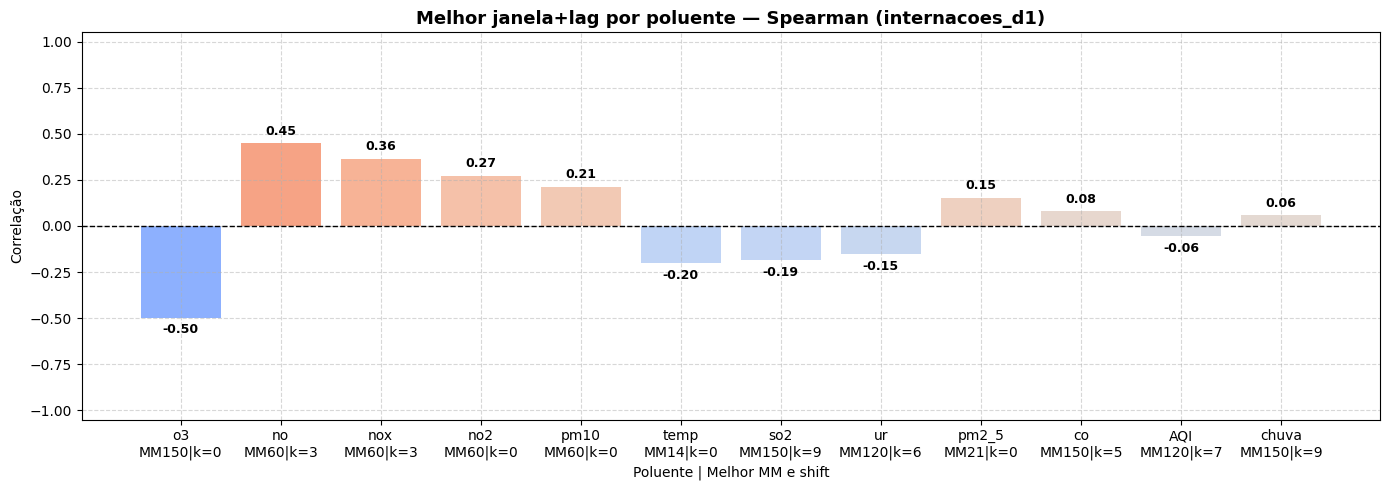


Melhores combinações por poluente — internacoes_d1:
   variavel  janela  shift  spearman
0        o3     150      0 -0.499179
1        no      60      3  0.449228
2       nox      60      3  0.363488
3       no2      60      0  0.271716
4      pm10      60      0  0.211361
5      temp      14      0 -0.203071
6       so2     150      9 -0.186230
7        ur     120      6 -0.153344
8     pm2_5      21      0  0.152215
9        co     150      5  0.079619
10      AQI     120      7 -0.057097
11    chuva     150      9  0.056680


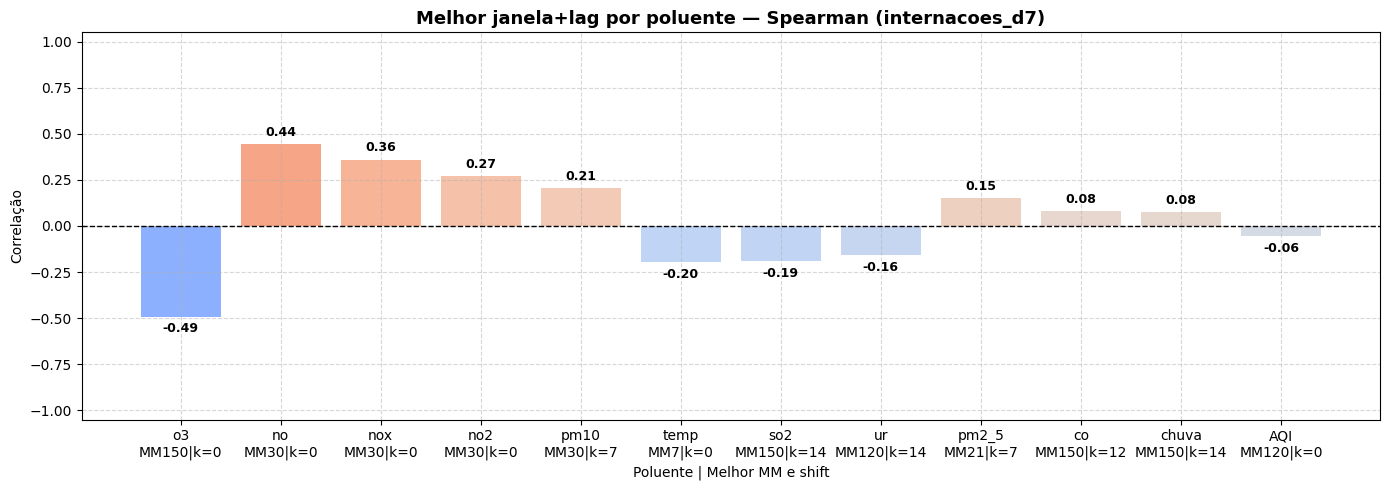


Melhores combinações por poluente — internacoes_d7:
   variavel  janela  shift  spearman
0        o3     150      0 -0.493323
1        no      30      0  0.442244
2       nox      30      0  0.358295
3       no2      30      0  0.268989
4      pm10      30      7  0.205023
5      temp       7      0 -0.196077
6       so2     150     14 -0.191125
7        ur     120     14 -0.159213
8     pm2_5      21      7  0.149468
9        co     150     12  0.079995
10    chuva     150     14  0.075308
11      AQI     120      0 -0.055790


In [8]:
import warnings
warnings.filterwarnings('ignore')

df = df_unificado.copy()

pollutant_candidates = ['co','no','no2','nox','so2','o3','pm10','pm2_5','AQI','temp','chuva','ur']
janelas = [3, 7, 14, 21, 30, 60, 90, 120, 150]
shifts_by_target = {
    "internacoes_d1": [0, 3, 5, 6, 7, 9],
    "internacoes_d7": [0, 7, 12, 13, 14]
}

cols_lower_map = {c.lower(): c for c in df.columns}
pollutants = [(v if v in df.columns else cols_lower_map.get(v.lower())) for v in pollutant_candidates]
pollutants = [v for v in dict.fromkeys(pollutants) if v is not None]

for c in pollutants + ["internacoes_d1","internacoes_d7"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for var in pollutants:
    s = df[var]
    for w in janelas:
        df[f"{var}_mm{w}"] = s.rolling(window=w, min_periods=w).mean()

results = []
for tgt, shifts in shifts_by_target.items():
    if tgt not in df.columns:
        continue
    for var in pollutants:
        for w in janelas:
            base_col = f"{var}_mm{w}"
            if base_col not in df.columns:
                continue
            for k in shifts:
                x = df[base_col].shift(k)
                y = df[tgt]
                sub = pd.concat([x, y], axis=1).dropna()
                if len(sub) >= 5:
                    corr = sub.corr(method="spearman").iloc[0,1]
                    results.append({"target": tgt, "variavel": var, "janela": w, "shift": k, "spearman": corr})

res = pd.DataFrame(results)
if res.empty:
    raise ValueError("Sem resultados (verifique colunas).")

best_per_var = (res.assign(abs_s=res["spearman"].abs())
                  .sort_values(["target","variavel","abs_s"], ascending=[True, True, False])
                  .groupby(["target","variavel"], as_index=False)
                  .first()
                  .drop(columns="abs_s"))

for tgt in ["internacoes_d1", "internacoes_d7"]:
    df_t = best_per_var[best_per_var["target"] == tgt].copy()
    if df_t.empty:
        continue
    df_t = df_t.sort_values("spearman", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
    labels = df_t.apply(lambda r: f"{r['variavel']}\nMM{int(r['janela'])}|k={int(r['shift'])}", axis=1)
    vals = df_t["spearman"].values
    colors = plt.cm.coolwarm((vals + 1) / 2)

    plt.figure(figsize=(max(14, 0.9*len(df_t)), 5))
    bars = plt.bar(labels, vals, color=colors)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.ylim(-1.05, 1.05)
    plt.title(f"Melhor janela+lag por poluente — Spearman ({tgt})", fontsize=13, fontweight="bold")
    plt.xlabel("Poluente | Melhor MM e shift")
    plt.ylabel("Correlação")
    plt.grid(True, linestyle="--", alpha=0.5)
    for rect, val in zip(bars, vals):
        x = rect.get_x() + rect.get_width()/2
        y = val + (0.03 if val >= 0 else -0.03)
        va = "bottom" if val >= 0 else "top"
        plt.text(x, y, f"{val:.2f}", ha="center", va=va, fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\nMelhores combinações por poluente — {tgt}:")
    print(df_t[["variavel","janela","shift","spearman"]].reset_index(drop=True))

In [9]:
import warnings
warnings.filterwarnings('ignore')

df = df_unificado.copy()

features_candidatas = ['chuva','temp','ur','co','no','no2','nox','so2','o3','pm10','pm2_5','AQI','aqi']
janelas = [3, 7, 14, 21, 30, 60, 90, 120, 150]
shifts_by_target = {
    "internacoes_d1": [0, 3, 5, 6, 7, 9],
    "internacoes_d7": [0, 7, 12, 13, 14]
}

cols_lower = {c.lower(): c for c in df.columns}
features = [(v if v in df.columns else cols_lower.get(v.lower())) for v in features_candidatas]
features = [v for v in dict.fromkeys(features) if v is not None]

for c in features + ["internacoes_d1","internacoes_d7"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for var in features:
    s = df[var]
    for w in janelas:
        df[f"{var}_mm{w}"] = s.rolling(window=w, min_periods=w).mean()

rows = []
for tgt, shifts in shifts_by_target.items():
    if tgt not in df.columns:
        continue
    y = df[tgt]
    for var in features:
        for w in janelas:
            base = f"{var}_mm{w}"
            if base not in df.columns:
                continue
            for k in shifts:
                x = df[base].shift(k)
                m = x.notna() & y.notna()
                n = int(m.sum())
                if n >= 5:
                    rho = pd.concat([x[m], y[m]], axis=1).corr(method="spearman").iloc[0,1]
                    rows.append({"target": tgt, "variavel": var, "janela": w, "shift": k, "n": n, "spearman": rho})

res = pd.DataFrame(rows).reset_index(drop=True)
df_ccf_d1 = (res[res["target"]=="internacoes_d1"]
             .sort_values(["variavel","janela","shift"])
             .reset_index(drop=True))
df_ccf_d7 = (res[res["target"]=="internacoes_d7"]
             .sort_values(["variavel","janela","shift"])
             .reset_index(drop=True))

print("df_ccf_d1:", df_ccf_d1.shape)
display(df_ccf_d1.sort_values("spearman", key=lambda s: s.abs(), ascending=False).head(10))
print("\ndf_ccf_d7:", df_ccf_d7.shape)
display(df_ccf_d7.sort_values("spearman", key=lambda s: s.abs(), ascending=False).head(10))

df_ccf_d1: (648, 6)


,target,variavel,janela,shift,n,spearman
372,internacoes_d1,o3,150,0,4276,-0.499179
373,internacoes_d1,o3,150,3,4273,-0.497211
374,internacoes_d1,o3,150,5,4271,-0.495441
375,internacoes_d1,o3,150,6,4270,-0.493323
376,internacoes_d1,o3,150,7,4269,-0.491330
377,internacoes_d1,o3,150,9,4267,-0.488072
366,internacoes_d1,o3,120,0,4366,-0.487559
368,internacoes_d1,o3,120,5,4361,-0.485609
367,internacoes_d1,o3,120,3,4363,-0.485434
369,internacoes_d1,o3,120,6,4360,-0.484602



df_ccf_d7: (540, 6)


,target,variavel,janela,shift,n,spearman
310,internacoes_d7,o3,150,0,4270,-0.493323
305,internacoes_d7,o3,120,0,4360,-0.484602
311,internacoes_d7,o3,150,7,4263,-0.481795
306,internacoes_d7,o3,120,7,4353,-0.478075
312,internacoes_d7,o3,150,12,4258,-0.476422
307,internacoes_d7,o3,120,12,4348,-0.475396
308,internacoes_d7,o3,120,13,4347,-0.474455
313,internacoes_d7,o3,150,13,4257,-0.474387
309,internacoes_d7,o3,120,14,4346,-0.473158
314,internacoes_d7,o3,150,14,4256,-0.471766


### Objetivo desta seção (curto)
Visualizar, em **séries semanais padronizadas (z-score)**, o co-movimento entre os alvos **`internacoes_d1`** e **`internacoes_d7`** e os **poluentes com melhor combinação de janela e defasagem** encontrada nas análises anteriores.  
- Poluentes usados: **O₃ (MM150, k=0)**, **NO** e **NOx** (para D+1: **MM60, k=3**; para D+7: **MM30, k=0**).  
- Agregação **semanal** e **suavização** do alvo para reduzir ruído e facilitar a leitura.


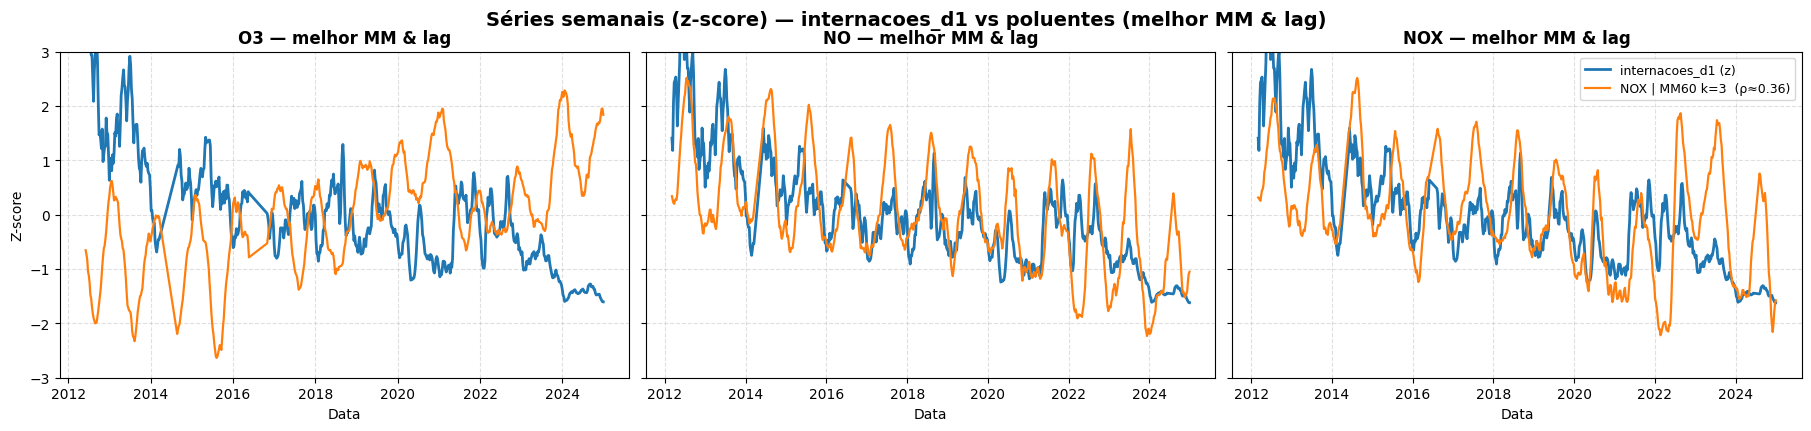

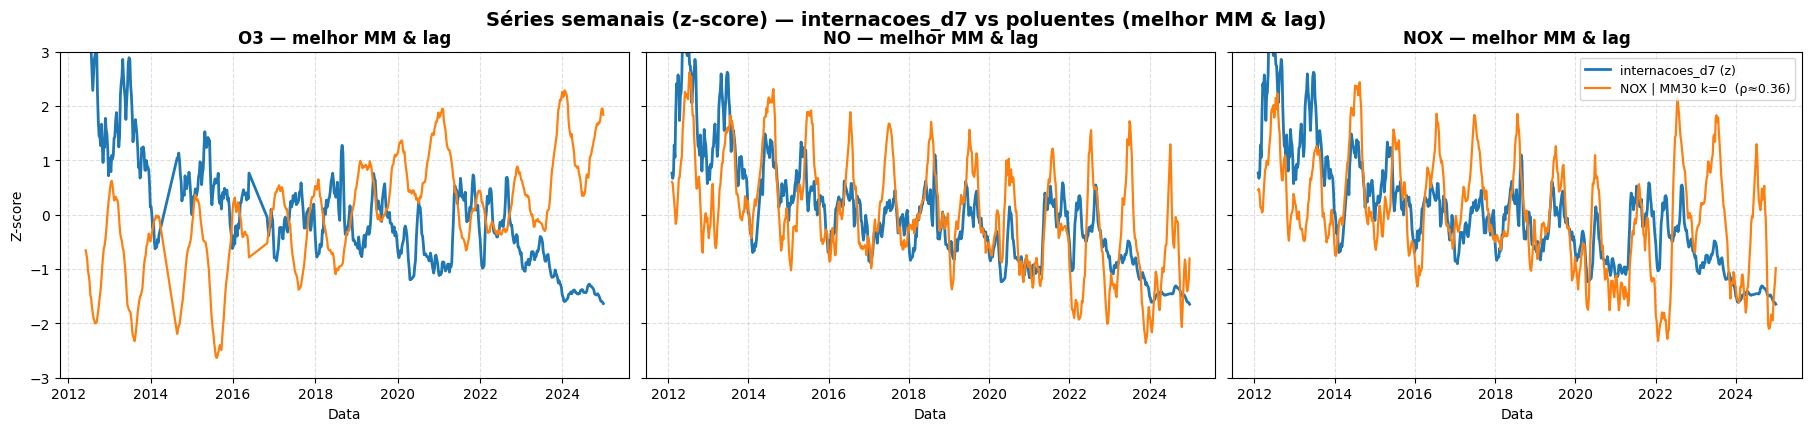

In [22]:
df = df_unificado.copy()
df["data_dia"] = pd.to_datetime(df["data_dia"], errors="coerce")
df = df.dropna(subset=["data_dia"]).sort_values("data_dia").set_index("data_dia")

specs_d1 = [
    {"var": "o3",  "win": 150, "shift": 0, "rho": -0.499179},
    {"var": "no",  "win":  60, "shift": 3, "rho":  0.449228},
    {"var": "nox", "win":  60, "shift": 3, "rho":  0.363488},
]
specs_d7 = [
    {"var": "o3",  "win": 150, "shift": 0, "rho": -0.493323},
    {"var": "no",  "win":  30, "shift": 0, "rho":  0.442244},
    {"var": "nox", "win":  30, "shift": 0, "rho":  0.358295},
]


FREQ = "W"      
SMOOTH = 4      
YLIM = (-3, 3)  
START = None    
END   = None    


def colname(df_cols_map, name):
    return name if name in df.columns else df_cols_map.get(name.lower())

def mm_shift(series, w, k):
    return series.rolling(window=w, min_periods=w).mean().shift(k)

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    m, sd = s.mean(), s.std(ddof=0)
    return (s - m) / sd if sd and not np.isnan(sd) else s*0

def build_pair(target_col, var, win, shift, freq=FREQ, smooth=SMOOTH):
    
    y = df[target_col].resample(freq).mean()
    y = y.rolling(smooth, min_periods=max(1, smooth//2)).mean()
    
    x_raw = pd.to_numeric(df[var], errors="coerce")
    x = mm_shift(x_raw, win, shift).resample(freq).mean()
    
    pair = pd.DataFrame({"y": y, "x": x}).dropna()
    pair["y_z"] = zscore(pair["y"])
    pair["x_z"] = zscore(pair["x"])
    if START or END:
        pair = pair.loc[slice(START, END)]
    return pair

def plot_block(target, specs):
    fig, axes = plt.subplots(1, len(specs), figsize=(6*len(specs), 4), sharey=True, constrained_layout=True)
    if len(specs) == 1: axes = [axes]
    cols_map = {c.lower(): c for c in df.columns}

    for ax, sp in zip(axes, specs):
        vcol = colname(cols_map, sp["var"])
        pair = build_pair(target, vcol, sp["win"], sp["shift"])
        ax.plot(pair.index, pair["y_z"], linewidth=2.0, label=f"{target} (z)")
        ax.plot(pair.index, pair["x_z"], linewidth=1.6, label=f"{sp['var'].upper()} | MM{sp['win']} k={sp['shift']}  (ρ≈{sp['rho']:.2f})")
        ax.set_ylim(*YLIM)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.set_title(f"{sp['var'].upper()} — melhor MM & lag", fontsize=12, fontweight="bold")
        ax.set_xlabel("Data")
    axes[0].set_ylabel("Z-score")
    axes[-1].legend(loc="upper right", fontsize=9, frameon=True)
    return fig

plot_block("internacoes_d1", specs_d1)
plt.suptitle("Séries semanais (z-score) — internacoes_d1 vs poluentes (melhor MM & lag)", y=1.04, fontsize=14, fontweight="bold")
plt.show()

plot_block("internacoes_d7", specs_d7)
plt.suptitle("Séries semanais (z-score) — internacoes_d7 vs poluentes (melhor MM & lag)", y=1.04, fontsize=14, fontweight="bold")
plt.show()


#### Resultados

**D+1 (internacoes_d1)**
- **O₃ (MM150, k=0)**: série **fora de fase** com o alvo → relação **negativa**, consistente com ρ≈**−0,50**.  
- **NO / NOx (MM60, k=3)**: **co-movimento positivo** com atraso curto (~**3 dias**), força **moderada** (ρ≈**0,45** e **0,36**).

**D+7 (internacoes_d7)**
- **O₃ (MM150, k=0)**: padrão negativo semelhante ao D+1 (ρ≈**−0,49**).  
- **NO / NOx (MM30, k=0)**: **co-movimento contemporâneo**, também **moderado** (ρ≈**0,44** e **0,36**).

**Notas**
- Padrões **não são perfeitos** (períodos de desacoplamento), mas a **tendência geral** se mantém: **NO/NOx  ↔ internações **; **O₃  ↔ internações **.  
- Interpretar como **associações**, não causalidade; em modelos, controlar **calendário** e **clima** e checar **colinearidade** NOx × O₃.


# Principais resultados

**Sinais consistentes**
- **NO/NOx/NO₂**: **correlação positiva** com as internações (moderada).  
- **O₃**: **correlação negativa** (fora de fase com o alvo).  
- **PM₁₀**: positiva **fraca**; **PM₂.₅** fraca/instável.  
- **Temperatura**: efeito **negativo** moderado; **chuva/UR** fracos.

**Defasagens e janelas mais informativas**
- **D+1**: picos de associação em ~**5–6 dias** (NO/NOx/NO₂ positivos, O₃ negativo).  
  - Destaques: **NO_MM60.shift(3)** (ρ≈**0,45**), **NOX_MM60.shift(3)** (ρ≈**0,36**), **O3_MM150** (ρ≈**−0,50**).
- **D+7**: maior força em **lag 0** (ecos semanais ~7/13).  
  - Destaques: **NO_MM30** (ρ≈**0,44**), **NOX_MM30** (ρ≈**0,36**), **O3_MM150** (ρ≈**−0,49**).
- **Médias móveis** (ex.: **MM7**) tendem a superar o valor pontual (efeito acumulado).

**Estabilidade temporal**
- Correlação rolante (365d): **NO/NO₂** medianas ~**0,20–0,23**; **O₃** ~**−0,12 a −0,15**; variação ao longo dos anos (p10–p90 amplos).

**Estudo de eventos (MM7 top 10%)**
- Após picos de **NO/NO₂**: **pequeno aumento** de internações nos dias seguintes.  
- Após picos de **O₃**: **queda** de internações no curto prazo.  
- Efeitos médios são **modestos** (~±1 internação), mas **consistentes** com as correlações.

**Implicação para modelagem**
- Features candidatas fortes:  
  - **D+1** → `NO_MM60.shift(3)`, `NOX_MM60.shift(3)`, `O3_MM150` (sinais +, +, −).  
  - **D+7** → `NO_MM30`, `NOX_MM30`, `O3_MM150` (sinais +, +, −).  
- Incluir **calendário** (dia-da-semana, mês) e **clima** (temp/UR) como controles e checar **colinearidade** (NOx × O₃).
